#  World Model — CliffWalking-v1

Entraîne 3 configurations :
- **Config 1** : Standard — S(t+1) direct
- **Config 2** : MultiStep — S(t+5) direct  
- **Config 3** : Delta — ΔS = S(t+1) - St

 Early stopping |  Checkpoints |  Évaluation test

## 1. Imports & Setup

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime


ENV_NAME = "CliffWalking-v1"
DATA_PATH = "../data/collected/CliffWalking"
CHECKPOINT_DIR = "world_model/checkpoints_CliffWalking"
PLOT_DIR = "world_model/plots_CliffWalking"


EPOCHS = 200
BATCH_SIZE = 256
LR = 1e-3
HIDDEN = 64
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)


np.random.seed(SEED)
torch.manual_seed(SEED)

print(f" Setup OK")
print(f"  Device: {DEVICE}")
print(f"  Data: {DATA_PATH}")
print(f"  Checkpoints: {CHECKPOINT_DIR}")

 Setup OK
  Device: cpu
  Data: ../data/collected/CliffWalking
  Checkpoints: world_model/checkpoints_CliffWalking


## 2. Charger les données

In [ ]:
def load_data():
    trans_path = os.path.join(DATA_PATH, "transitions.npz")
    trans = np.load(trans_path, allow_pickle=True)
    
    scaler_path = os.path.join(DATA_PATH, "scaler.npz")
    scaler = np.load(scaler_path, allow_pickle=True)
    
    return trans, scaler


trans, scaler = load_data()


S_tr_oh = trans["states_train"].astype(np.float32) 
A_tr = trans["actions_train"].astype(np.int32)
A_tr_oh = trans["actions_onehot_train"].astype(np.float32)  
NS_tr_oh = trans["next_states_train"].astype(np.float32)  

S_va_oh = trans["states_val"].astype(np.float32)
A_va = trans["actions_val"].astype(np.int32)
A_va_oh = trans["actions_onehot_val"].astype(np.float32)
NS_va_oh = trans["next_states_val"].astype(np.float32)

S_te_oh = trans["states_test"].astype(np.float32)
A_te = trans["actions_test"].astype(np.int32)
A_te_oh = trans["actions_onehot_test"].astype(np.float32)
NS_te_oh = trans["next_states_test"].astype(np.float32)

reward_mean = float(scaler["reward_mean"])
reward_std = float(scaler["reward_std"])

STATE_DIM = S_tr_oh.shape[1] 
ACTION_DIM = A_tr_oh.shape[1] 
N_STEPS = 2

print(f"\nDonnées chargées (CliffWalking - États one-hot)")
print(f"  STATE_DIM: {STATE_DIM}")
print(f"  ACTION_DIM: {ACTION_DIM}")
print(f"  Train: {len(S_tr_oh):,} | Val: {len(S_va_oh):,} | Test: {len(S_te_oh):,}")
print(f"  Reward mean={reward_mean:.4f}, std={reward_std:.4f}")


 Données chargées (CliffWalking - États one-hot)
  STATE_DIM: 48
  ACTION_DIM: 4
  Train: 140,038 | Val: 19,614 | Test: 40,348
  Reward mean=-10.5898, std=29.2818


## 3. Architecture WorldModel

In [ ]:
class WorldModel(nn.Module):
    """
    Réseau de prédiction d'état (3 configs).

    Config 1 : in = obs_dim + act_dim          → S(t+1) absolu
    Config 2 : in = obs_dim + n_step * act_dim → S(t+n) absolu
    Config 3 : in = obs_dim + act_dim          → ΔS  (S+ΔS dans predict())
    """

    def __init__(self, obs_dim: int, act_dim: int,
                 config: int = 3, n_step: int = 5,
                 hidden: int = HIDDEN):
        super().__init__()
        assert config in (1, 2, 3), 

        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.config = config
        self.n_step = n_step if config == 2 else 1

        in_dim = obs_dim + (n_step * act_dim if config == 2 else act_dim)

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, obs_dim),
        )

    def forward(self, state: torch.Tensor,
                action_input: torch.Tensor) -> torch.Tensor:
        """
        state        : (batch, obs_dim)
        action_input : (batch, act_dim)              configs 1 & 3
                     | (batch, n_step * act_dim)     config  2
        retourne     : (batch, obs_dim)
        """
        return self.net(torch.cat([state, action_input], dim=-1))

    def predict(self, state: torch.Tensor,
                action_input: torch.Tensor) -> torch.Tensor:
        """Retourne toujours un état absolu (applique S+ΔS pour config 3)."""
        out = self.forward(state, action_input)
        return state + out if self.config == 3 else out


print(" Architecture WorldModel définie")

 Architecture WorldModel définie


## 4. Early Stopping

In [ ]:
class EarlyStopping:
    
    def __init__(self, patience: int = 8, min_delta: float = 1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float("inf")
        self.num_bad = 0

    def step(self, loss: float) -> bool:
        if loss < self.best - self.min_delta:
            self.best = loss
            self.num_bad = 0
            return False
        self.num_bad += 1
        return self.num_bad >= self.patience


print(" EarlyStopping défini")

 EarlyStopping défini


## 5. Construction des datasets

In [ ]:
def build_dataset_config1_3(S_oh, A_oh, NS_oh, config: int):
    """
    Configs 1 & 3 : construire (X, Y) depuis transitions individuelles.
    
    Config 1 : X=[s_oh|a_oh]  Y=ns_oh
    Config 3 : X=[s_oh|a_oh]  Y=ns_oh - s_oh  (ΔS one-hot delta)
    """
    assert config in (1, 3), "Config 1 ou 3 uniquement"
    
    X = np.concatenate([S_oh, A_oh], axis=1).astype(np.float32)
    Y = NS_oh - S_oh if config == 3 else NS_oh
    Y = Y.astype(np.float32)
    
    return torch.FloatTensor(X).to(DEVICE), torch.FloatTensor(Y).to(DEVICE)


def build_dataset_config2():
    """
    Config 2 : MultiStep — construire (X, Y) depuis sequences_n2.npz.
    
    X = [S0_oh | A0_oh | A1_oh | ... | An-1_oh]
    Y = S(t+n)_oh
    """
    seq_path = os.path.join(DATA_PATH, "sequences_n2.npz")
    seq = np.load(seq_path, allow_pickle=True)
    
    S_n_tr = seq["states_train"].astype(np.float32)  
    A_oh_n_tr = seq["actions_onehot_train"].astype(np.float32)  
    SN_n_tr = seq["states_n_train"].astype(np.float32) 
    
    M_tr = len(S_n_tr)
    n_step = A_oh_n_tr.shape[1]
    
    A_flat_tr = A_oh_n_tr.reshape(M_tr, -1)  
    X_tr = np.concatenate([S_n_tr, A_flat_tr], axis=1).astype(np.float32)
    Y_tr = SN_n_tr.astype(np.float32)
    
    S_n_va = seq["states_val"].astype(np.float32)
    A_oh_n_va = seq["actions_onehot_val"].astype(np.float32)
    SN_n_va = seq["states_n_val"].astype(np.float32)
    
    M_va = len(S_n_va)
    A_flat_va = A_oh_n_va.reshape(M_va, -1)
    X_va = np.concatenate([S_n_va, A_flat_va], axis=1).astype(np.float32)
    Y_va = SN_n_va.astype(np.float32)
    
    S_n_te = seq["states_test"].astype(np.float32)
    A_oh_n_te = seq["actions_onehot_test"].astype(np.float32)
    SN_n_te = seq["states_n_test"].astype(np.float32)
    
    M_te = len(S_n_te)
    A_flat_te = A_oh_n_te.reshape(M_te, -1)
    X_te = np.concatenate([S_n_te, A_flat_te], axis=1).astype(np.float32)
    Y_te = SN_n_te.astype(np.float32)
    
    print(f"  Config 2 (MultiStep, n={n_step}):")
    print(f"    Train: {X_tr.shape[0]:,} | Val: {X_va.shape[0]:,} | Test: {X_te.shape[0]:,}")
    
    return (
        torch.FloatTensor(X_tr).to(DEVICE), torch.FloatTensor(Y_tr).to(DEVICE),
        torch.FloatTensor(X_va).to(DEVICE), torch.FloatTensor(Y_va).to(DEVICE),
        torch.FloatTensor(X_te).to(DEVICE), torch.FloatTensor(Y_te).to(DEVICE),
    )


print(f"\n Construction datasets...")
print(f"\n  Config 1 & 3 (Transitions individuelles, one-hot):")
X_tr_c1, Y_tr_c1 = build_dataset_config1_3(S_tr_oh, A_tr_oh, NS_tr_oh, config=1)
X_va_c1, Y_va_c1 = build_dataset_config1_3(S_va_oh, A_va_oh, NS_va_oh, config=1)
X_te_c1, Y_te_c1 = build_dataset_config1_3(S_te_oh, A_te_oh, NS_te_oh, config=1)
print(f"    Train: {X_tr_c1.shape[0]:,} | Val: {X_va_c1.shape[0]:,} | Test: {X_te_c1.shape[0]:,}")

X_tr_c3, Y_tr_c3 = build_dataset_config1_3(S_tr_oh, A_tr_oh, NS_tr_oh, config=3)
X_va_c3, Y_va_c3 = build_dataset_config1_3(S_va_oh, A_va_oh, NS_va_oh, config=3)
X_te_c3, Y_te_c3 = build_dataset_config1_3(S_te_oh, A_te_oh, NS_te_oh, config=3)

print(f"\n  Config 2 (MultiStep sequences):")
X_tr_c2, Y_tr_c2, X_va_c2, Y_va_c2, X_te_c2, Y_te_c2 = build_dataset_config2()

print(f"\n Datasets construits")


 Construction datasets...

  Config 1 & 3 (Transitions individuelles, one-hot):
    Train: 140,038 | Val: 19,614 | Test: 40,348

  Config 2 (MultiStep sequences):
  Config 2 (MultiStep, n=2):
    Train: 138,620 | Val: 19,413 | Test: 39,942

 Datasets construits


## 6. Entraînement

In [ ]:
def train_world_model(config: int, X_tr, Y_tr, X_va, Y_va, X_te, Y_te):

    print(f"\n{'='*70}")
    print(f"  WorldModel | env={ENV_NAME} | config={config}")
    print(f"  device={DEVICE} | hidden={HIDDEN} | epochs={EPOCHS}")
    print(f"{'='*70}\n")

    train_loader = DataLoader(TensorDataset(X_tr, Y_tr),
                              batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_va, Y_va),
                            batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_te, Y_te),
                             batch_size=BATCH_SIZE, shuffle=False)

    n_step = 2 if config == 2 else 1
    model = WorldModel(STATE_DIM, ACTION_DIM, config, n_step, HIDDEN).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=LR)
    sched = optim.lr_scheduler.StepLR(opt, step_size=15, gamma=0.5)
    loss_fn = nn.MSELoss()
    stopper = EarlyStopping(patience=8)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"[WM] Paramètres : {n_params:,}\n")

    # Boucle d'entraînement
    best_val = float("inf")
    best_sd = None
    tr_losses, val_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            s_b = xb[:, :STATE_DIM]
            a_b = xb[:, STATE_DIM:]
            pred = model.forward(s_b, a_b)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader.dataset)
        tr_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                s_b = xb[:, :STATE_DIM]
                a_b = xb[:, STATE_DIM:]
                pred = model.forward(s_b, a_b)
                val_loss += loss_fn(pred, yb).item() * len(xb)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        sched.step()

        if val_loss < best_val:
            best_val = val_loss
            best_sd = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS} | "
                  f"train={train_loss:.6f} | "
                  f"val={val_loss:.6f} | "
                  f"best_val={best_val:.6f} | "
                  f"lr={sched.get_last_lr()[0]:.1e}")

        if stopper.step(val_loss):
            print(f"\n[WM] Early stopping à l'epoch {epoch} (best_val={best_val:.6f})")
            break

    model.load_state_dict(best_sd)
    model.eval()

    test_mse = 0.0
    test_mae = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            s_b = xb[:, :STATE_DIM]
            a_b = xb[:, STATE_DIM:]
            pred = model.forward(s_b, a_b)
            test_mse += loss_fn(pred, yb).item() * len(xb)
            test_mae += torch.mean(torch.abs(pred - yb)).item() * len(xb)
    
    test_mse /= len(test_loader.dataset)
    test_mae /= len(test_loader.dataset)
    print(f"\n[TEST] MSE={test_mse:.6f} | MAE={test_mae:.6f}")

    tag = f"config{config}" + (f"_n2" if config == 2 else "")
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"wm_{ENV_NAME}_{tag}.pt")
    torch.save({
        "state_dict": model.state_dict(),
        "config": config,
        "obs_dim": STATE_DIM,
        "act_dim": ACTION_DIM,
        "hidden": HIDDEN,
        "reward_mean": reward_mean,
        "reward_std": reward_std,
    }, ckpt_path)
    print(f"\n[SAVE] → {ckpt_path}")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(tr_losses, label="Train Loss", linewidth=2)
    ax.plot(val_losses, label="Val Loss", linewidth=2)
    ax.axhline(best_val, color="red", linestyle="--", label=f"Best Val: {best_val:.6f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Learning Curve — Config {config} ({ENV_NAME})")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    
    plot_path = os.path.join(PLOT_DIR, f"losses_config{config}_{ENV_NAME}.png")
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"[PLOT] → {plot_path}")

    return model, best_val, test_mse, test_mae


print("Fonction d'entraînement définie")

 Fonction d'entraînement définie


## 7. Entraîner Config 1 (Standard)


  WorldModel | env=CliffWalking-v1 | config=1
  device=cpu | hidden=64 | epochs=200

[WM] Paramètres : 14,832

  Epoch   1/200 | train=0.005760 | val=0.001099 | best_val=0.001099 | lr=1.0e-03
  Epoch   5/200 | train=0.000185 | val=0.000202 | best_val=0.000202 | lr=1.0e-03
  Epoch  10/200 | train=0.000048 | val=0.000065 | best_val=0.000065 | lr=1.0e-03
  Epoch  15/200 | train=0.000025 | val=0.000038 | best_val=0.000037 | lr=5.0e-04
  Epoch  20/200 | train=0.000015 | val=0.000150 | best_val=0.000025 | lr=5.0e-04
  Epoch  25/200 | train=0.000009 | val=0.000012 | best_val=0.000012 | lr=5.0e-04
  Epoch  30/200 | train=0.000005 | val=0.000009 | best_val=0.000008 | lr=2.5e-04
  Epoch  35/200 | train=0.000004 | val=0.000005 | best_val=0.000005 | lr=2.5e-04
  Epoch  40/200 | train=0.000003 | val=0.000006 | best_val=0.000004 | lr=2.5e-04
  Epoch  45/200 | train=0.000002 | val=0.000003 | best_val=0.000003 | lr=1.3e-04
  Epoch  50/200 | train=0.000001 | val=0.000002 | best_val=0.000002 | lr=1.3e-

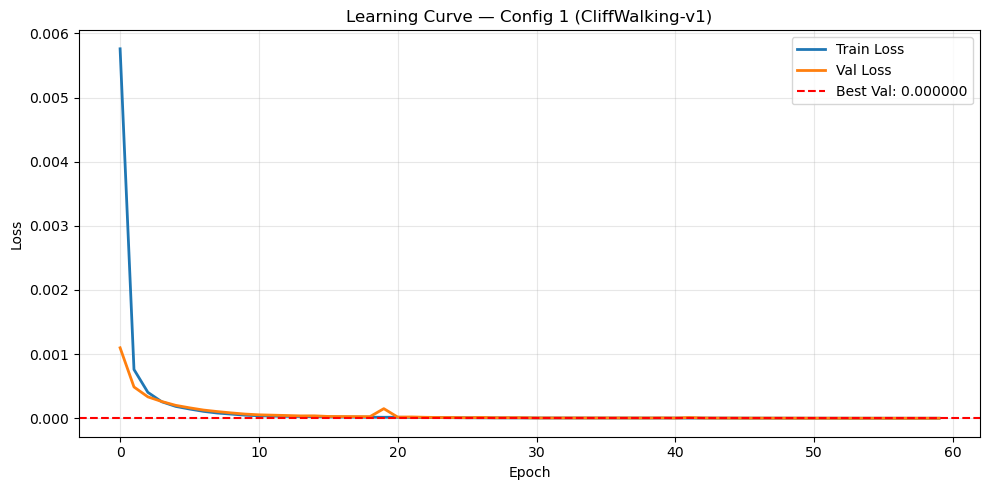

[PLOT] → world_model/plots_CliffWalking/losses_config1_CliffWalking-v1.png


In [18]:
model_c1, best_val_c1, test_mse_c1, test_mae_c1 = train_world_model(
    config=1,
    X_tr=X_tr_c1, Y_tr=Y_tr_c1,
    X_va=X_va_c1, Y_va=Y_va_c1,
    X_te=X_te_c1, Y_te=Y_te_c1,
)

## 8. Entraîner Config 2 (MultiStep)


  WorldModel | env=CliffWalking-v1 | config=2
  device=cpu | hidden=64 | epochs=200

[WM] Paramètres : 15,088

  Epoch   1/200 | train=0.008482 | val=0.002902 | best_val=0.002902 | lr=1.0e-03
  Epoch   5/200 | train=0.000525 | val=0.000466 | best_val=0.000466 | lr=1.0e-03
  Epoch  10/200 | train=0.000216 | val=0.000235 | best_val=0.000235 | lr=1.0e-03
  Epoch  15/200 | train=0.000131 | val=0.000162 | best_val=0.000162 | lr=5.0e-04
  Epoch  20/200 | train=0.000099 | val=0.000126 | best_val=0.000126 | lr=5.0e-04
  Epoch  25/200 | train=0.000074 | val=0.000093 | best_val=0.000093 | lr=5.0e-04
  Epoch  30/200 | train=0.000055 | val=0.000066 | best_val=0.000066 | lr=2.5e-04
  Epoch  35/200 | train=0.000045 | val=0.000055 | best_val=0.000055 | lr=2.5e-04
  Epoch  40/200 | train=0.000039 | val=0.000047 | best_val=0.000047 | lr=2.5e-04
  Epoch  45/200 | train=0.000034 | val=0.000041 | best_val=0.000041 | lr=1.3e-04
  Epoch  50/200 | train=0.000030 | val=0.000038 | best_val=0.000038 | lr=1.3e-

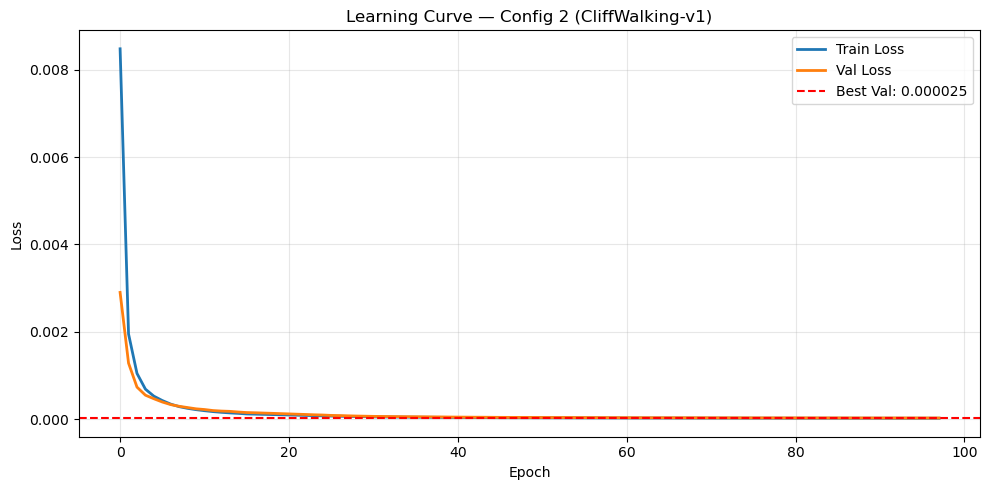

[PLOT] → world_model/plots_CliffWalking/losses_config2_CliffWalking-v1.png


In [19]:
model_c2, best_val_c2, test_mse_c2, test_mae_c2 = train_world_model(
    config=2,
    X_tr=X_tr_c2, Y_tr=Y_tr_c2,
    X_va=X_va_c2, Y_va=Y_va_c2,
    X_te=X_te_c2, Y_te=Y_te_c2,
)

## 9. Entraîner Config 3 (Delta)


  WorldModel | env=CliffWalking-v1 | config=3
  device=cpu | hidden=64 | epochs=200

[WM] Paramètres : 14,832

  Epoch   1/200 | train=0.008942 | val=0.001945 | best_val=0.001945 | lr=1.0e-03
  Epoch   5/200 | train=0.000450 | val=0.000482 | best_val=0.000482 | lr=1.0e-03
  Epoch  10/200 | train=0.000215 | val=0.000295 | best_val=0.000295 | lr=1.0e-03
  Epoch  15/200 | train=0.000134 | val=0.000177 | best_val=0.000177 | lr=5.0e-04
  Epoch  20/200 | train=0.000104 | val=0.000140 | best_val=0.000140 | lr=5.0e-04
  Epoch  25/200 | train=0.000076 | val=0.000106 | best_val=0.000106 | lr=5.0e-04
  Epoch  30/200 | train=0.000061 | val=0.000090 | best_val=0.000090 | lr=2.5e-04
  Epoch  35/200 | train=0.000054 | val=0.000078 | best_val=0.000078 | lr=2.5e-04
  Epoch  40/200 | train=0.000049 | val=0.000072 | best_val=0.000072 | lr=2.5e-04
  Epoch  45/200 | train=0.000044 | val=0.000063 | best_val=0.000063 | lr=1.3e-04
  Epoch  50/200 | train=0.000040 | val=0.000056 | best_val=0.000056 | lr=1.3e-

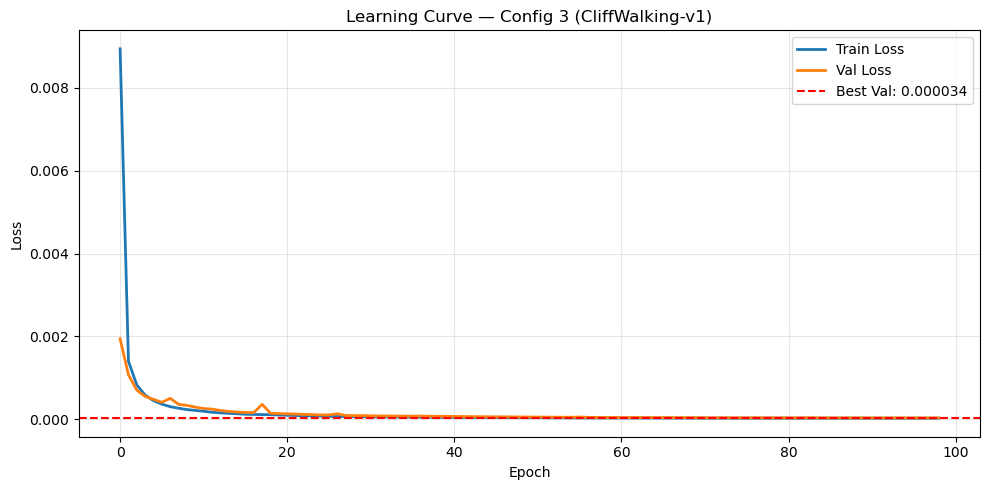

[PLOT] → world_model/plots_CliffWalking/losses_config3_CliffWalking-v1.png


In [20]:
model_c3, best_val_c3, test_mse_c3, test_mae_c3 = train_world_model(
    config=3,
    X_tr=X_tr_c3, Y_tr=Y_tr_c3,
    X_va=X_va_c3, Y_va=Y_va_c3,
    X_te=X_te_c3, Y_te=Y_te_c3,
)

## 10. Résumé & Comparaison

In [ ]:
print(f"\n{'='*70}")
print(f"  RÉSUMÉ DES 3 CONFIGURATIONS — {ENV_NAME}")
print(f"{'='*70}\n")

results = [
    ("Config 1 (Standard)", best_val_c1, test_mse_c1, test_mae_c1),
    ("Config 2 (MultiStep n=2)", best_val_c2, test_mse_c2, test_mae_c2),
    ("Config 3 (Delta)", best_val_c3, test_mse_c3, test_mae_c3),
]

for name, best_val, test_mse, test_mae in results:
    print(f"{name}:")
    print(f"  Best Val Loss: {best_val:.6f}")
    print(f"  Test MSE:     {test_mse:.6f}")
    print(f"  Test MAE:     {test_mae:.6f}")
    print()

best_config = min(results, key=lambda x: x[1])
print(f" Meilleure config: {best_config[0]} (Val Loss: {best_config[1]:.6f})")
print(f"\n Entraînement terminé! Checkpoints sauvegardés dans {CHECKPOINT_DIR}")


  RÉSUMÉ DES 3 CONFIGURATIONS — CliffWalking-v1

Config 1 (Standard):
  Best Val Loss: 0.000000
  Test MSE:     0.000000
  Test MAE:     0.000254

Config 2 (MultiStep n=2):
  Best Val Loss: 0.000025
  Test MSE:     0.000021
  Test MAE:     0.001244

Config 3 (Delta):
  Best Val Loss: 0.000034
  Test MSE:     0.000025
  Test MAE:     0.000756

 Meilleure config: Config 1 (Standard) (Val Loss: 0.000000)

 Entraînement terminé! Checkpoints sauvegardés dans world_model/checkpoints_CliffWalking


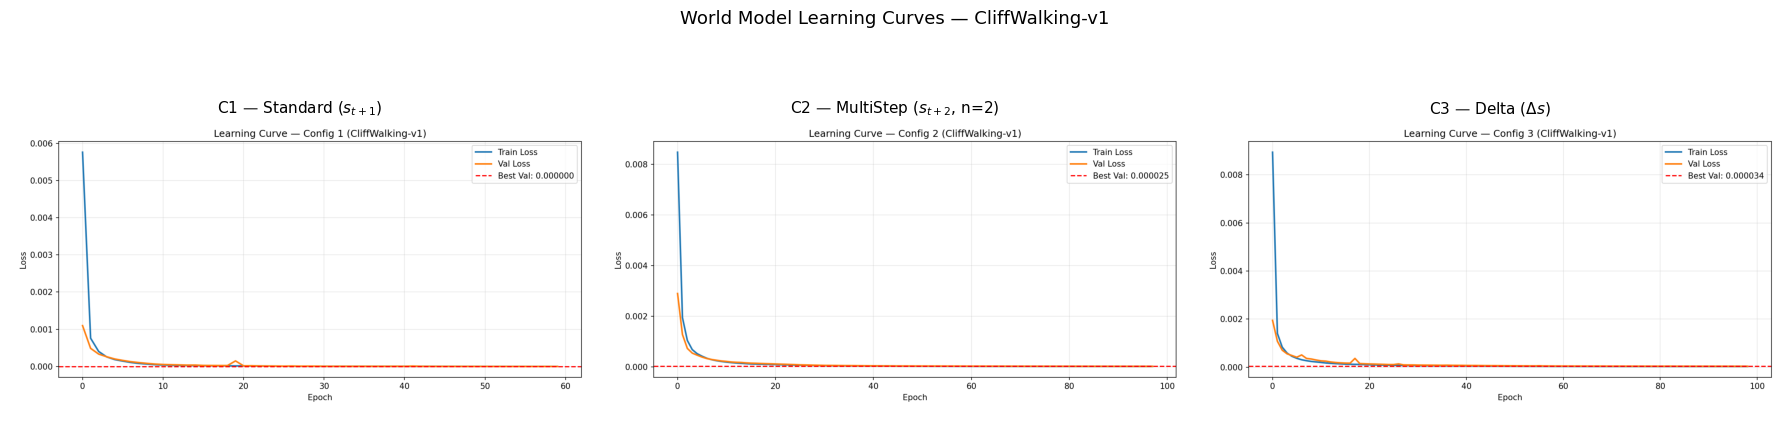

Saved → losses_all_configs_CliffWalking-v1.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

img_c1 = mpimg.imread(os.path.join(PLOT_DIR, "losses_config1_CliffWalking-v1.png"))
img_c2 = mpimg.imread(os.path.join(PLOT_DIR, "losses_config2_CliffWalking-v1.png"))
img_c3 = mpimg.imread(os.path.join(PLOT_DIR, "losses_config3_CliffWalking-v1.png"))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("World Model Learning Curves — CliffWalking-v1", fontsize=13)

for ax, img, title in zip(axes,
                           [img_c1, img_c2, img_c3],
                           ["C1 — Standard ($s_{t+1}$)",
                            "C2 — MultiStep ($s_{t+2}$, n=2)",
                            "C3 — Delta ($\\Delta s$)"]):
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "losses_all_configs_CliffWalking-v1.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → losses_all_configs_CliffWalking-v1.png")